In [ ]:
import os
import torch
from torch.utils.data import DataLoader,Dataset
from torchvision import transforms
from PIL import Image

In [ ]:
from torch.utils import data
#image load=>transform =>dataset of all imgs
class ImageProcessor:
    def __init__(self,dataset_path,transformations=None):
        self.dataset_path=dataset_path
        self.transformations=transformations

        #list of paths for all images
        self.all_img_paths=[os.path.join(dataset_path,img) for img in os.listdir(dataset_path)]
    def __len__(self):
        return len(self.all_img_paths)
    def __getitem__(self,idx):
        img_path=self.all_img_paths[idx]
        img=Image.open(img_path).convert("RGB")

        if self.transformations:
            img=self.transformations(img)
        return img

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/img_align_celeba.zip -d /content/img_align_celeba

Streaming output truncated to the last 5000 lines.
 extracting: /content/img_align_celeba/img_align_celeba/197600.jpg  
 extracting: /content/img_align_celeba/img_align_celeba/197601.jpg  
 extracting: /content/img_align_celeba/img_align_celeba/197602.jpg  
 extracting: /content/img_align_celeba/img_align_celeba/197603.jpg  
 extracting: /content/img_align_celeba/img_align_celeba/197604.jpg  
 extracting: /content/img_align_celeba/img_align_celeba/197605.jpg  
 extracting: /content/img_align_celeba/img_align_celeba/197606.jpg  
 extracting: /content/img_align_celeba/img_align_celeba/197607.jpg  
 extracting: /content/img_align_celeba/img_align_celeba/197608.jpg  
 extracting: /content/img_align_celeba/img_align_celeba/197609.jpg  
 extracting: /content/img_align_celeba/img_align_celeba/197610.jpg  
 extracting: /content/img_align_celeba/img_align_celeba/197611.jpg  
 extracting: /content/img_align_celeba/img_align_celeba/197612.jpg  
 extracting: /content/img_align_celeba/img_align_cel

In [ ]:
dataset_path='/content/img_align_celeba/img_align_celeba'

In [ ]:

transformations=transforms.Compose([
    transforms.CenterCrop(178), #178 X 218 -> 178x 178
    transforms.Resize(64), #64x64
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)) #[-1,1]
])

In [ ]:
dataset=ImageProcessor(dataset_path,transformations)
print(f"loaded {len(dataset)} images")

loaded 202599 images


In [ ]:
dataloader=DataLoader(dataset,batch_size=128,shuffle=True)

In [ ]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [ ]:
class Generator(nn.Module):
    def __init__(self,z_dim=100,img_channels=3): #3 is for RGB
        super(Generator,self).__init__()

        #fully connected (dense) layers
        self.model=nn.Sequential(
            nn.Linear(z_dim,256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,1024),
            nn.ReLU(),

            nn.Linear(1024,64 *64 *img_channels),
            nn.Tanh() #[-1,1]
        )
    def forward(self,z):
        img=self.model(z)
        img=img.view(img.size(0),3,64,64)
        return img
        #fake img=>64 x 64 x 3 x batch_size

In [ ]:
class Discriminator(nn.Module):
    def __init__(self,img_channels=3): #3 is for RGB
        super(Discriminator,self).__init__()

        #fully connected (dense) layers
        self.model=nn.Sequential(
            nn.Flatten(), # 4D tensor convert 1D

            nn.Linear(img_channels*64*64,1024),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(1024,512),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(256,1),
            nn.Sigmoid() #probability of being real/fake
        )
    def forward(self,img):
        return self.model(img)

In [ ]:
GAN_loss=nn.BCELoss()
generator=Generator()
g_optimizer=optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.999))

discriminator=Discriminator()
d_optimizer=optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))

In [ ]:
import torch
#device
if torch.backends.mps.is_available():
    device=torch.device("mps")
elif torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")
print(f"device is {device}")

device is cuda


In [ ]:
generator=generator.to(device)
discriminator=discriminator.to(device)

In [ ]:
def train(generator,discriminator,dataloader,epochs=10):
    for epoch in range(epochs):
        for i ,imgs in enumerate(dataloader):
            real_imgs=imgs.to(device)
            batch_size=real_imgs.size(0)

            #creates real img labels & fake imgs labels
            real_labels=torch.ones(batch_size,1).to(device)
            fake_labels=torch.zeros(batch_size,1).to(device)

            #Train the discriminator
            d_optimizer.zero_grad()
            fake_imgs=generator(torch.randn(batch_size,100).to(device))
            real_loss=GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss=GAN_loss(discriminator(fake_imgs.detach()),fake_labels)

            d_loss=(real_loss+fake_loss)/2

            d_loss.backward()
            d_optimizer.step()

            # Train the generator
            g_optimizer.zero_grad()
            g_loss=GAN_loss(discriminator(fake_imgs),real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i%50 ==0:
                print(f"for epoch:{epoch+1}/{epochs}..batch:{i+1}... G-loss:{g_loss}....D-loss:{d_loss}")
        # save generated imgs for each epoch
        save_generated_images(generator,epoch,device)

In [ ]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch:1/5..batch:1... G-loss:0.6905059814453125....D-loss:0.6931204199790955
for epoch:1/5..batch:51... G-loss:1.0497132539749146....D-loss:0.25323808193206787
for epoch:1/5..batch:101... G-loss:2.0252366065979004....D-loss:0.3315926790237427
for epoch:1/5..batch:151... G-loss:2.0356087684631348....D-loss:0.09555841237306595
for epoch:1/5..batch:201... G-loss:0.5240544080734253....D-loss:0.572842538356781
for epoch:1/5..batch:251... G-loss:1.8257904052734375....D-loss:0.1857903003692627
for epoch:1/5..batch:301... G-loss:2.4941623210906982....D-loss:0.07620254904031754
for epoch:1/5..batch:351... G-loss:3.0296077728271484....D-loss:0.11041601002216339
for epoch:1/5..batch:401... G-loss:3.9055252075195312....D-loss:0.10186032950878143
for epoch:1/5..batch:451... G-loss:2.324131965637207....D-loss:0.14230607450008392
for epoch:1/5..batch:501... G-loss:3.2090370655059814....D-loss:0.11638756096363068
for epoch:1/5..batch:551... G-loss:3.2405831813812256....D-loss:0.04836494103074074
f

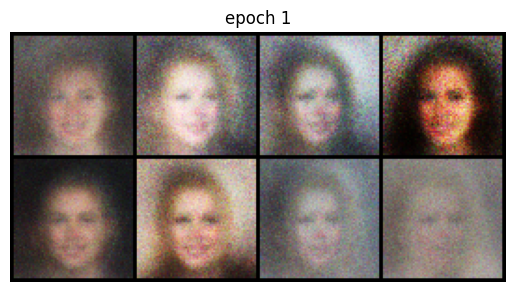

for epoch:2/5..batch:1... G-loss:3.56997013092041....D-loss:0.3013700842857361
for epoch:2/5..batch:51... G-loss:3.290963649749756....D-loss:0.5091052055358887
for epoch:2/5..batch:101... G-loss:1.6622226238250732....D-loss:0.41206538677215576
for epoch:2/5..batch:151... G-loss:2.857123851776123....D-loss:0.33024492859840393
for epoch:2/5..batch:201... G-loss:2.150686264038086....D-loss:0.4478091597557068
for epoch:2/5..batch:251... G-loss:1.9558899402618408....D-loss:0.38120388984680176
for epoch:2/5..batch:301... G-loss:2.4687066078186035....D-loss:0.29565587639808655
for epoch:2/5..batch:351... G-loss:3.3713746070861816....D-loss:0.4385386109352112
for epoch:2/5..batch:401... G-loss:2.321460723876953....D-loss:0.4375534653663635
for epoch:2/5..batch:451... G-loss:2.86057710647583....D-loss:0.410541296005249
for epoch:2/5..batch:501... G-loss:2.4762942790985107....D-loss:0.35186606645584106
for epoch:2/5..batch:551... G-loss:3.523024559020996....D-loss:0.4576798677444458
for epoch:2/

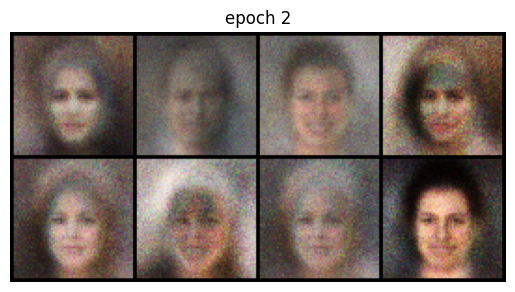

for epoch:3/5..batch:1... G-loss:2.1200103759765625....D-loss:0.3599598705768585
for epoch:3/5..batch:51... G-loss:1.9161314964294434....D-loss:0.4519948363304138
for epoch:3/5..batch:101... G-loss:1.8405576944351196....D-loss:0.4434666633605957
for epoch:3/5..batch:151... G-loss:2.3998053073883057....D-loss:0.42186301946640015
for epoch:3/5..batch:201... G-loss:1.9685494899749756....D-loss:0.35918885469436646
for epoch:3/5..batch:251... G-loss:1.8184400796890259....D-loss:0.42213761806488037
for epoch:3/5..batch:301... G-loss:2.0810933113098145....D-loss:0.3758971393108368
for epoch:3/5..batch:351... G-loss:1.7538169622421265....D-loss:0.5479839444160461
for epoch:3/5..batch:401... G-loss:1.6916170120239258....D-loss:0.3593751788139343
for epoch:3/5..batch:451... G-loss:1.6831985712051392....D-loss:0.4675031900405884
for epoch:3/5..batch:501... G-loss:2.0896477699279785....D-loss:0.4196770191192627
for epoch:3/5..batch:551... G-loss:2.0402932167053223....D-loss:0.4004621207714081
for 

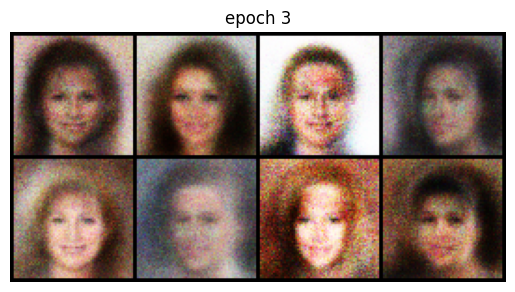

for epoch:4/5..batch:1... G-loss:1.3751485347747803....D-loss:0.5407348871231079
for epoch:4/5..batch:51... G-loss:2.200779438018799....D-loss:0.4021732211112976
for epoch:4/5..batch:101... G-loss:1.6412456035614014....D-loss:0.5588427782058716
for epoch:4/5..batch:151... G-loss:2.04538631439209....D-loss:0.46332231163978577
for epoch:4/5..batch:201... G-loss:2.1486215591430664....D-loss:0.5271706581115723
for epoch:4/5..batch:251... G-loss:1.4280459880828857....D-loss:0.5446540117263794
for epoch:4/5..batch:301... G-loss:1.8930178880691528....D-loss:0.4265816807746887
for epoch:4/5..batch:351... G-loss:1.9241032600402832....D-loss:0.49005943536758423
for epoch:4/5..batch:401... G-loss:2.2776689529418945....D-loss:0.5319991111755371
for epoch:4/5..batch:451... G-loss:1.5265514850616455....D-loss:0.6307659149169922
for epoch:4/5..batch:501... G-loss:1.5770323276519775....D-loss:0.5214403867721558
for epoch:4/5..batch:551... G-loss:1.7948250770568848....D-loss:0.46197426319122314
for epo

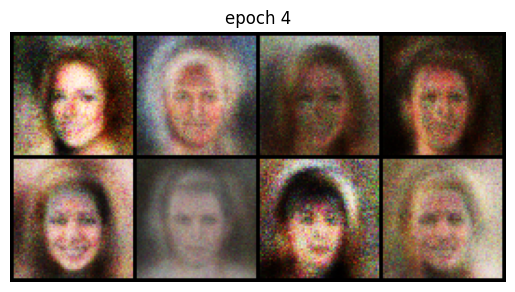

for epoch:5/5..batch:1... G-loss:1.865079641342163....D-loss:0.4854774475097656
for epoch:5/5..batch:51... G-loss:1.6493192911148071....D-loss:0.4955277144908905
for epoch:5/5..batch:101... G-loss:1.6852900981903076....D-loss:0.5288355946540833
for epoch:5/5..batch:151... G-loss:2.2251055240631104....D-loss:0.5837317705154419
for epoch:5/5..batch:201... G-loss:1.4505329132080078....D-loss:0.5588833093643188
for epoch:5/5..batch:251... G-loss:1.681786060333252....D-loss:0.48291119933128357
for epoch:5/5..batch:301... G-loss:1.5248544216156006....D-loss:0.560470700263977
for epoch:5/5..batch:351... G-loss:1.749047040939331....D-loss:0.5480266809463501
for epoch:5/5..batch:401... G-loss:1.586836338043213....D-loss:0.4843639135360718
for epoch:5/5..batch:451... G-loss:1.5244314670562744....D-loss:0.48857107758522034
for epoch:5/5..batch:501... G-loss:1.8443516492843628....D-loss:0.6250418424606323
for epoch:5/5..batch:551... G-loss:1.51082444190979....D-loss:0.5513596534729004
for epoch:5/

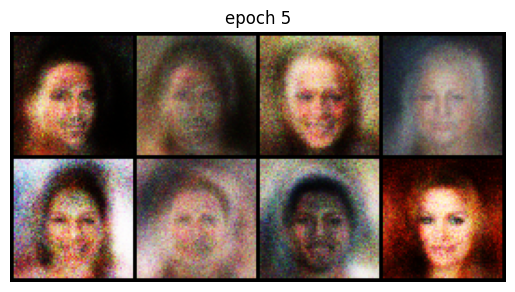

In [ ]:
train(generator,discriminator,dataloader,epochs=5)